In [1]:
from aqua.diagnostics import ssh_variability_compute, ssh_variability_plot
from aqua import Reader
import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path
# import gc

/home/a/a270260/.conda/envs/aqua-dev/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/home/a/a270260/.conda/envs/aqua-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def init_state(template: xr.DataArray) -> dict:
    """
    Initialize empty state from a template DataArray (e.g. first slice)
    """
    zero_array = xr.zeros_like(template.isel(time=0)).compute()
    return {
        "count":           0,
        "start_timestamp": template.isel(time=0).time.values,
        "end_timestamp":   template.isel(time=0).time.values,
        "m1":              zero_array.copy(),             
        "m2":              zero_array.copy(),
        "m3":              zero_array.copy(),
        "m4":              zero_array.copy(),
    }

def save_state(state: dict, var: str ,path: str = "./"):
    """
    Saving the state
    """
    start_str = pd.Timestamp(state["start_timestamp"]).strftime("%Y-%m-%d")
    end_str   = pd.Timestamp(state["end_timestamp"]).strftime("%Y-%m-%d")
    
    ds = xr.Dataset({
        f"{var}_m1":       state["m1"].drop_vars("time", errors="ignore"),
        f"{var}_m2":       state["m2"].drop_vars("time", errors="ignore"),
        f"{var}_m3":       state["m3"].drop_vars("time", errors="ignore"),
        f"{var}_m4":       state["m4"].drop_vars("time", errors="ignore"),
    })
    ds.attrs["start_timestamp"] = start_str
    ds.attrs["end_timestamp"]   = end_str
    ds.attrs["count"]           = state["count"]
    
    dir_path = Path(path)
    dir_path.mkdir(parents=True, exist_ok=True)
    
    filename = f"{path}/welford_state_{start_str}_to_{end_str}.nc"
    ds.to_netcdf(filename)

def load_state(filename: str, var: str) -> dict:
    """
    Loading the state
    """
    ds = xr.open_dataset(filename)
    return {
        "count":           ds.attrs["count"],
        "start_timestamp": pd.Timestamp(ds.attrs["start_timestamp"]),
        "end_timestamp":   pd.Timestamp(ds.attrs["end_timestamp"]),
        "m1":              ds[f"{var}_m1"].rename(var),
        "m2":              ds[f"{var}_m2"].rename(var),
        "m3":              ds[f"{var}_m3"].rename(var),
        "m4":              ds[f"{var}_m4"].rename(var),
    }

def welford_std(state: dict, ddof=0) -> xr.DataArray:
    """
    Compute std from current state
    """
    return np.sqrt(state["m2"] / (state["count"] - ddof))

def welford_statistics(var: str, 
                     data: xr.DataArray=None, 
                     state: dict=None, 
                     dim: str="time",
                     statistics: dict = {"variance": True, "skewness_kurtosis": True},
                     ddof: int=0, 
                     fillnan: bool=True, 
                     outputdir: str="./", 
                     state_save: bool=True):
    """
    Welford's online variance along a given dimension.
    This can be made more generalized for all other dimensions.
    
    ddof=1: sample variance (unbiased, matches np.var(ddof=1))
    ddof=0: population variance
    """
    # TODO: 
    #      Test Skipna vs fillna(0)
    #      For now, fillna(0) is used in order to compare the results with 
    #      Skipna
    if state==None:
        state = init_state(data)

    count = state["count"]
    start_timestamp = state["start_timestamp"] 
    end_timestamp = state["end_timestamp"]

    # fill NaN's as ZEROS
    if fillnan:
        m1 = state["m1"].fillna(0)
        m2 = state["m2"].fillna(0)
        m3 = state["m3"].fillna(0)
        m4 = state["m4"].fillna(0)
    else:
        m1 = state["m1"]
        m2 = state["m2"]
        m3 = state["m3"]
        m4 = state["m4"]

    # TODO:
    #      Which chunk to be loaded
    #      Either month or each Timestamp
    #      In some case loading monthly chunk is slower than loading
    #      each Timestamp
    for month_label, ds_month in data.resample(time="MS"):
        ds_month.load() 
        # iterates over the leading (time) dimension
        for x in ds_month:          
            # x.load()
            count += 1
            if fillnan: x = x.fillna(0) # with fillnan as ZEROS    
            # compute delta ONCE — reused in both updates
            delta   = (x - m1).compute()   # diff from OLD mean
            delta_n = delta / count          # fractional adjustment
            if statistics["variance"]:
                delta_n2 = delta_n * delta_n
                term1   = delta * delta_n * (count - 1)

                if statistics["skewness_kurtosis"]:
                    # M4 uses old m2 and old m3
                    m4 = m4 + (term1 * delta_n2 * (count * count - 3 * count + 3)
                               + 6 * delta_n2 * m2
                               - 4 * delta_n  * m3)
                    # M3 uses old m2
                    m3 = m3 + (term1 * delta_n * (count - 2)
                               - 3 * delta_n * m2)

            # M2 and M1 last
            if statistics["variance"]: m2 = m2 + term1
            m1 = m1 + delta_n
        
    nan_template = xr.full_like(data.isel({dim: 0}).compute(), fill_value=float("nan"))

    if state_save:
        state = {"count": count, "start_timestamp": start_timestamp, "end_timestamp": x.time.values, "m1": m1, "m2": m2, "m3": m3, "m4": m4}
        save_state(state=state, var=var, path=outputdir)
        
    if count < 2:
        return {k: nan_template for k in ("mean", "variance", "skewness", "kurtosis")}

    variance = m2 / (count - ddof)

    # FIX 2: Clip m2 to avoid RuntimeWarnings from floating-point noise
    m2_safe = m2.clip(min=0)
    if statistics["variance"] is True and statistics["skewness_kurtosis"] is True:
        skewness = xr.where(
            (m2 > 0) & (count >= 3),
            (np.sqrt(count) * m3) / (m2_safe ** 1.5),
            nan_template,
        )

        kurtosis = xr.where(
            (m2 > 0) & (count >= 4),
            (count * m4) / (m2_safe * m2_safe) - 3.0,
            nan_template,
        )
    if statistics["variance"] is True and statistics["skewness_kurtosis"] is True:
        return {
            "mean":     m1,
            "variance": variance,
            "skewness": skewness,
            "kurtosis": kurtosis,
        }
    else:
        return {
            "mean":     m1,
            "variance": variance,
        }

In [3]:
# Inputs for the function
# Outputdir
outputdir = "./AVISO_ssh" 
var = "adt"
startdate_0="1993-01-01"; enddate_0="2000-12-31"; # Test 00
startdate_1="2001-01-01"; enddate_1="2024-12-31"; # Test 01
_startdate="1993-01-01"; _enddate="2024-12-31";   # Full time interval
statistics = {"variance": True, "skewness_kurtosis": False}

In [4]:
## Test 00: AVISO STD from 1993-01-01 to 2000-12-31
dataset_dict_ref = {"catalog": "obs", "model": "AVISO", "exp":"vDT2024", "source":"daily-zarr"}
reader0 = Reader(**dataset_dict_ref, startdate=startdate_0, enddate=enddate_0, fix=True)
data0 = reader0.retrieve()
data0 = data0[var]

2026-04-07 00:34:44 :: Regridder :: WARNING  -> Source grid path not found. Please provide a dataset.
2026-04-07 00:34:44 :: Reader :: WARNING  -> Issues in the Regridder() init: trying with data
2026-04-07 00:34:56 :: Reader :: WARNING  -> Variable crs has no units!
2026-04-07 00:34:56 :: Reader :: WARNING  -> Variable flag_ice has no units!
2026-04-07 00:34:56 :: Reader :: WARNING  -> Variable lat_bnds has no units!
2026-04-07 00:34:56 :: Reader :: WARNING  -> Variable lon_bnds has no units!


In [5]:
######### Test 01 STD from 1993-01-01 to 2024-12-31

# Using Reader class we load the data 
# from 2001-01-01 to 2024-12-31 

# and we will load the welford variance state 
# from 1993-01-01 to 2000-12-31

reader1 = Reader(**dataset_dict_ref, startdate=startdate_1, enddate=enddate_1, fix=True)
data1 = reader1.retrieve()
data1 = data1[var]

2026-04-07 00:34:56 :: Regridder :: WARNING  -> Source grid path not found. Please provide a dataset.
2026-04-07 00:34:56 :: Reader :: WARNING  -> Issues in the Regridder() init: trying with data
2026-04-07 00:35:02 :: Reader :: WARNING  -> Variable crs has no units!
2026-04-07 00:35:02 :: Reader :: WARNING  -> Variable flag_ice has no units!
2026-04-07 00:35:02 :: Reader :: WARNING  -> Variable lat_bnds has no units!
2026-04-07 00:35:02 :: Reader :: WARNING  -> Variable lon_bnds has no units!


In [6]:
%%time
# TEST 00
# STD from 1993-01-01 to 2000-12-31
welford_stats0 = welford_statistics(data=data0, var=var, fillnan=True, statistics=statistics, state_save=True, outputdir=outputdir)
welford_std0 = np.sqrt(welford_stats0["variance"])

CPU times: user 1min 10s, sys: 49.6 s, total: 2min
Wall time: 2min 3s


In [7]:
%%time 
# the xarray's built-in STD function for comparison 
# STD from 1993-01-01 to 2000-12-31
std0 = data0.std(dim="time", skipna=True).compute()

CPU times: user 41.3 s, sys: 48.7 s, total: 1min 30s
Wall time: 1min 30s


/home/a/a270260/.conda/envs/aqua-dev/lib/python3.12/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


In [8]:
# load welford variance state from 1993-01-01 to 2000-12-31
state_0_path = f"{outputdir}/welford_state_{startdate_0}_to_{enddate_0}.nc"
state0 = load_state(state_0_path, var=var)

In [9]:
%%time
# TEST 01 
# from 2001-01-01 to 2024-12-31 
welford_stats0 = welford_statistics(data=data1, state=state0, var=var, fillnan=True, statistics=statistics, state_save=True, outputdir=outputdir)
welford_std1 = np.sqrt(welford_stats0["variance"])

CPU times: user 3min 33s, sys: 2min 28s, total: 6min 1s
Wall time: 6min 7s


In [10]:
## Compare the built-in STD function with Welford 
## for data from 1993-01-01 to 2024-12-31

_reader = Reader(**dataset_dict_ref, startdate=_startdate, enddate=_enddate, fix=True)
_data = _reader.retrieve()
_data = _data[var]

2026-04-07 00:44:45 :: Regridder :: WARNING  -> Source grid path not found. Please provide a dataset.
2026-04-07 00:44:45 :: Reader :: WARNING  -> Issues in the Regridder() init: trying with data
2026-04-07 00:44:50 :: Reader :: WARNING  -> Variable crs has no units!
2026-04-07 00:44:50 :: Reader :: WARNING  -> Variable flag_ice has no units!
2026-04-07 00:44:50 :: Reader :: WARNING  -> Variable lat_bnds has no units!
2026-04-07 00:44:50 :: Reader :: WARNING  -> Variable lon_bnds has no units!


In [11]:
%%time
# STD using xarray from 1993-01-01 to 2024-12-31
_std = _data.std(dim="time", skipna=True).compute()

CPU times: user 2min 44s, sys: 3min 13s, total: 5min 57s
Wall time: 6min 4s


/home/a/a270260/.conda/envs/aqua-dev/lib/python3.12/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


In [12]:
# This is the current ssh compute class without the welford implementation
# startdate_0="1993-01-01"; enddate_0="2024-12-31";
# ssh_dataset_0 = ssh_variability_compute(
#                     **dataset_dict_ref,
#                     startdate=startdate_ref_0,
#                     enddate=enddate_ref_0,
#                     var='adt')
# ssh_dataset_ref_0.run()

In [13]:
#####################################
###### Plotting the results #########
#####################################

In [14]:
##### Test 00

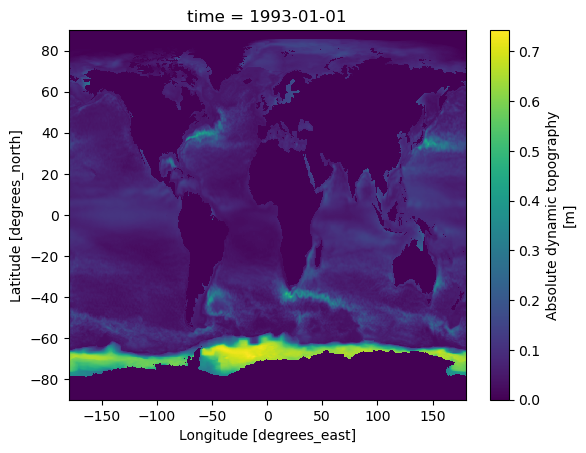

In [15]:
## Quick plot Welford NaN as ZEROs
welford_std0.plot()

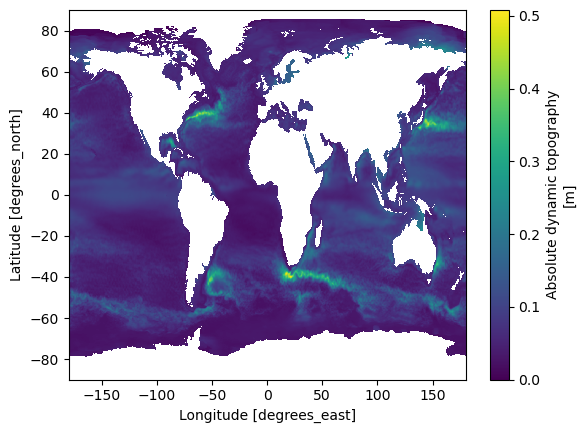

In [16]:
## Built-in STD skipna=True
std0.plot()

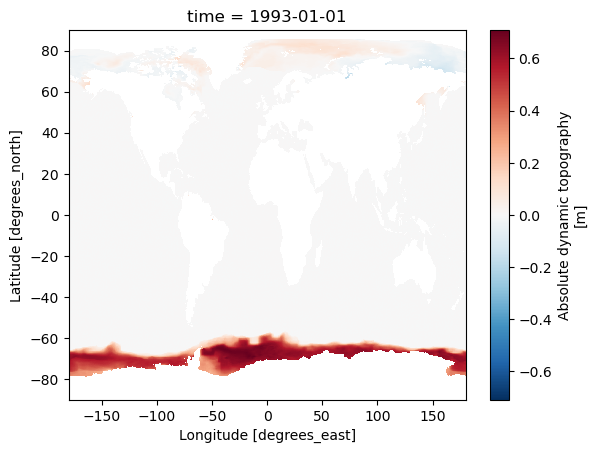

In [17]:
### Compare the Welford implementation with the built-in xarray std implementation
(welford_std0 - std0).plot()

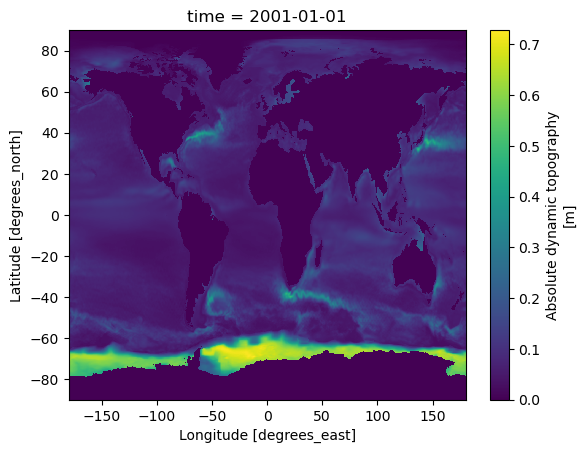

In [18]:
##### Test 01
## NaNs as ZEROs
welford_std1.plot()

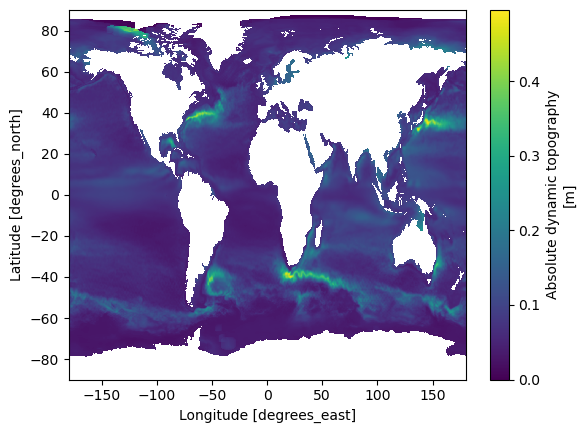

In [19]:
## Built-in STD from from 1993-01-01 to 2024-12-31 
## skipna=True
_std.plot()

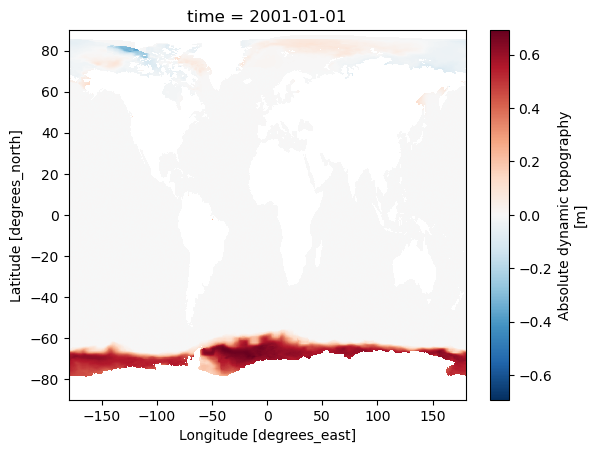

In [20]:
### Compare the Welford implementation with the built-in xarray std implementation
diff = welford_std1 - _std
diff.plot()

In [21]:
###### SSH plotting class #########

In [22]:
# Initialize the SSH plot class
plot_class = ssh_variability_plot(loglevel="INFO")
# It is important to choose a correct 'tgt_grid_name' so that the data aligns with land mask
# tgt_grid_name = "r1440x721"
tgt_grid_name = "r1440x720"

2026-04-07 00:51:01 :: PlotSsh_variability :: INFO     -> Plotting SSH Variability for AVISO and vDT2024, from 1993-01-01 to 2024-12-31.
2026-04-07 00:51:01 :: PlotSsh_variability :: INFO     -> Regridding model data and reference data using target grid name r1440x720 and regrid method ycon
2026-04-07 00:51:01 :: Regridder :: WARNING  -> No cfg_grid_dict dictionary provided, only CDO grid names can be used.
2026-04-07 00:51:01 | smmregrid.GridInspect |     INFO -> Updating the log_level to INFO
2026-04-07 00:51:01 | smmregrid.GridInspect |     INFO -> Data is already an xarray Dataset or DataArray
2026-04-07 00:51:01 :: Regridder :: INFO     -> Using provided dataset as a grid path for 2d
2026-04-07 00:51:01 :: Regridder :: INFO     -> Grid name: None
2026-04-07 00:51:01 :: Regridder :: WARNING  -> Weights block not found in the configuration file, using fallback naming scheme.
2026-04-07 00:51:01 :: Regridder :: INFO     -> Loading existing weights from weights_r1440x720_ycon_l2d.nc.


(<Figure size 1100x850 with 2 Axes>,
 <GeoAxes: title={'center': 'SSH Variability of Absolute dynamic topography for obs AVISO vDT2024 1993-01-01-2024-12-31'}, xlabel='Longitude', ylabel='Latitude'>)

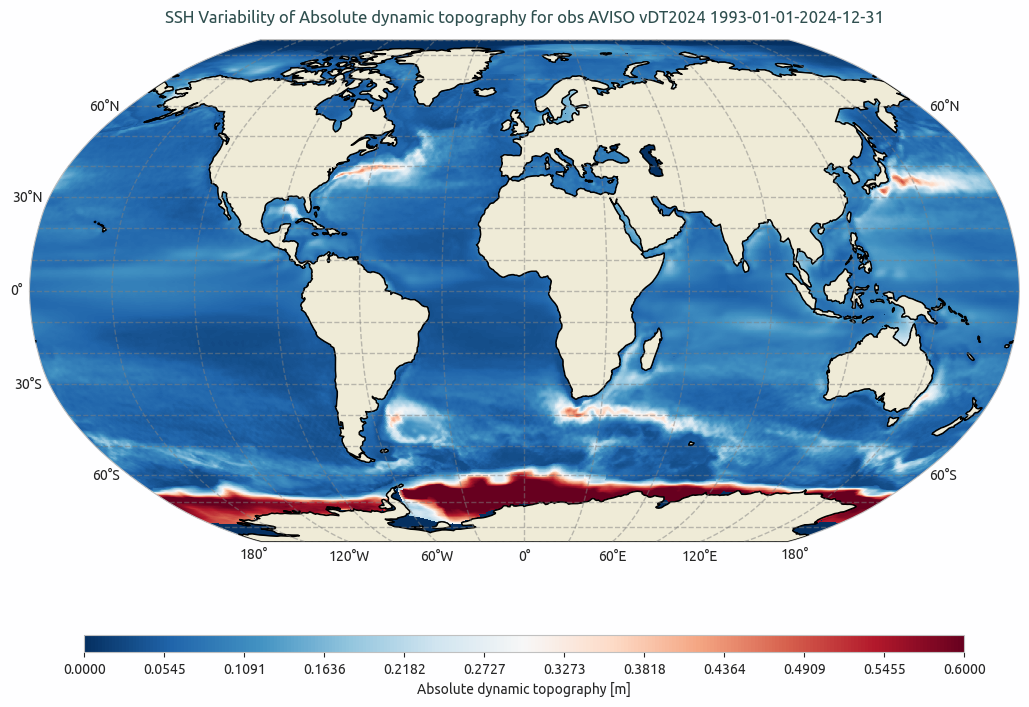

In [23]:
# Test 01 compare: Plot SSH from 2000-01-01 to 2002-12-31 (Welford)
# It is important to choose a correct 'tgt_grid_name' so that the data aligns with land mask
plot_dataset_ref = {"catalog": "obs", "model": "AVISO", "exp":"vDT2024", "tgt_grid_name":tgt_grid_name}

plot_class.plot(dataset_std=welford_std1, **plot_dataset_ref, startdate=_startdate, enddate=_enddate, vmin=0.0, vmax=0.6)

2026-04-07 00:52:29 :: PlotSsh_variability :: INFO     -> Plotting SSH Variability for AVISO and vDT2024, from 1993-01-01 to 2024-12-31.
2026-04-07 00:52:29 :: PlotSsh_variability :: INFO     -> Regridding model data and reference data using target grid name r1440x720 and regrid method ycon
2026-04-07 00:52:29 :: Regridder :: WARNING  -> No cfg_grid_dict dictionary provided, only CDO grid names can be used.
2026-04-07 00:52:29 | smmregrid.GridInspect |     INFO -> Data is already an xarray Dataset or DataArray
2026-04-07 00:52:29 :: Regridder :: INFO     -> Using provided dataset as a grid path for 2d
2026-04-07 00:52:29 :: Regridder :: INFO     -> Grid name: None
2026-04-07 00:52:29 :: Regridder :: WARNING  -> Weights block not found in the configuration file, using fallback naming scheme.
2026-04-07 00:52:29 :: Regridder :: INFO     -> Loading existing weights from weights_r1440x720_ycon_l2d.nc.
2026-04-07 00:52:29 | smmregrid.GridInspect |     INFO -> Data is already an xarray Datas

(<Figure size 1100x850 with 2 Axes>,
 <GeoAxes: title={'center': 'SSH Variability of Absolute dynamic topography for obs AVISO vDT2024 1993-01-01-2024-12-31'}, xlabel='Longitude', ylabel='Latitude'>)

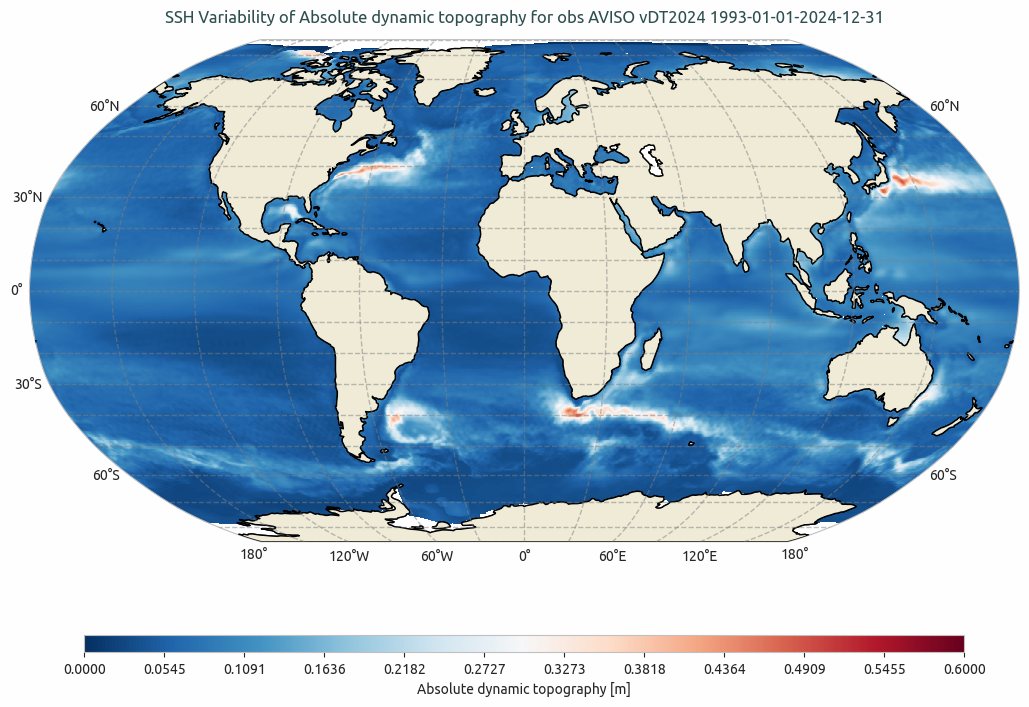

In [24]:
# Test 01 compare: Plot SSH from 2000-01-01 to 2002-12-31 (built-in)
# It is important to choose a correct 'tgt_grid_name' so that the data aligns with land mask
plot_dataset_ref = {"catalog": "obs", "model": "AVISO", "exp":"vDT2024", "tgt_grid_name":tgt_grid_name}

plot_class.plot(dataset_std=_std, **plot_dataset_ref, startdate=_startdate, enddate=_enddate, vmin=0.0, vmax=0.6)

2026-04-07 00:53:45 :: PlotSsh_variability :: INFO     -> Plotting SSH Variability for AVISO and vDT2024, from 1993-01-01 to 2024-12-31.
2026-04-07 00:53:45 :: PlotSsh_variability :: INFO     -> Regridding model data and reference data using target grid name r1440x720 and regrid method ycon
2026-04-07 00:53:45 :: Regridder :: WARNING  -> No cfg_grid_dict dictionary provided, only CDO grid names can be used.
2026-04-07 00:53:45 | smmregrid.GridInspect |     INFO -> Data is already an xarray Dataset or DataArray
2026-04-07 00:53:45 :: Regridder :: INFO     -> Using provided dataset as a grid path for 2d
2026-04-07 00:53:45 :: Regridder :: INFO     -> Grid name: None
2026-04-07 00:53:45 :: Regridder :: WARNING  -> Weights block not found in the configuration file, using fallback naming scheme.
2026-04-07 00:53:45 :: Regridder :: INFO     -> Loading existing weights from weights_r1440x720_ycon_l2d.nc.
2026-04-07 00:53:45 | smmregrid.GridInspect |     INFO -> Data is already an xarray Datas

CPU times: user 1min 1s, sys: 351 ms, total: 1min 1s
Wall time: 1min 2s


(<Figure size 1100x850 with 2 Axes>,
 <GeoAxes: title={'center': 'SSH Variability of Absolute dynamic topography for obs AVISO vDT2024 1993-01-01-2024-12-31'}, xlabel='Longitude', ylabel='Latitude'>)

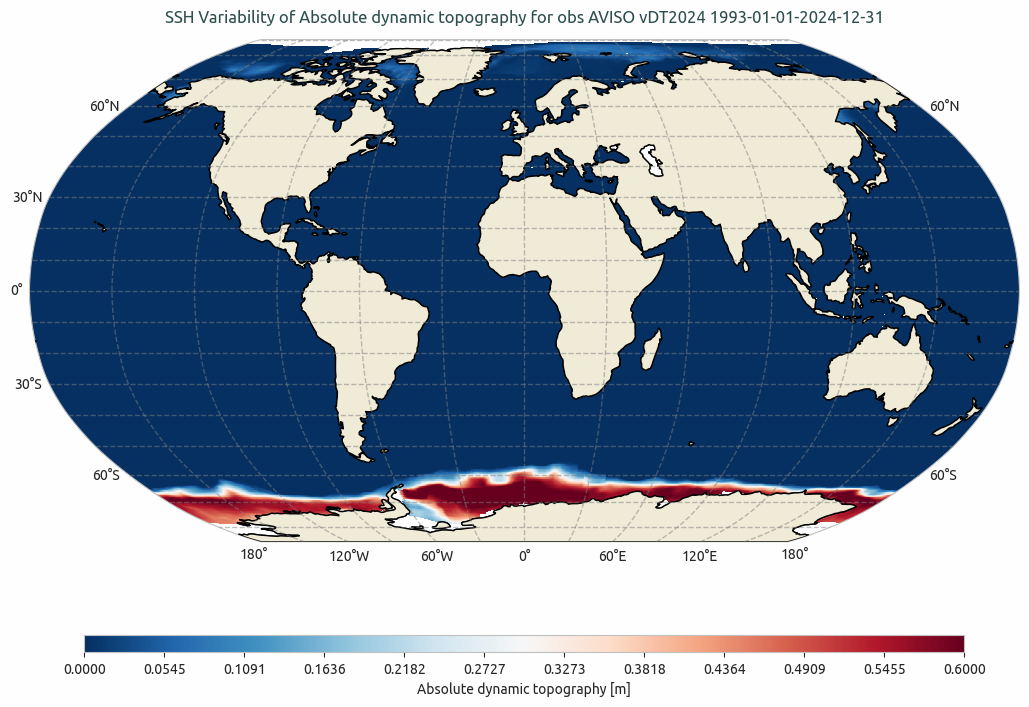

In [25]:
%%time
# Test 01 compare: Plot SSH difference from 2000-01-01 to 2002-12-31
# It is important to choose a correct 'tgt_grid_name' so that the data aligns with land mask
plot_dataset_ref = {"catalog": "obs", "model": "AVISO", "exp":"vDT2024", "tgt_grid_name":tgt_grid_name}

plot_class.plot(dataset_std=diff, **plot_dataset_ref, startdate=_startdate, enddate=_enddate, vmin=0.0, vmax=0.6)

2026-04-07 00:54:52 :: PlotSsh_variability :: INFO     -> Plotting SSH Variability for AVISO and vDT2024, from 1993-01-01 to 2024-12-31.
2026-04-07 00:54:52 :: PlotSsh_variability :: INFO     -> Regridding model data and reference data using target grid name r1440x720 and regrid method ycon
2026-04-07 00:54:52 :: Regridder :: WARNING  -> No cfg_grid_dict dictionary provided, only CDO grid names can be used.
2026-04-07 00:54:52 | smmregrid.GridInspect |     INFO -> Data is already an xarray Dataset or DataArray
2026-04-07 00:54:52 :: Regridder :: INFO     -> Using provided dataset as a grid path for 2d
2026-04-07 00:54:52 :: Regridder :: INFO     -> Grid name: None
2026-04-07 00:54:52 :: Regridder :: WARNING  -> Weights block not found in the configuration file, using fallback naming scheme.
2026-04-07 00:54:52 :: Regridder :: INFO     -> Loading existing weights from weights_r1440x720_ycon_l2d.nc.
2026-04-07 00:54:52 | smmregrid.GridInspect |     INFO -> Data is already an xarray Datas

CPU times: user 2.61 s, sys: 13.2 ms, total: 2.63 s
Wall time: 2.69 s


(<Figure size 1100x850 with 2 Axes>,
 <GeoAxes: title={'center': 'SSH Variability of Absolute dynamic topography [Agulhas] for obs AVISO vDT2024 1993-01-01-2024-12-31'}, xlabel='Longitude', ylabel='Latitude'>)

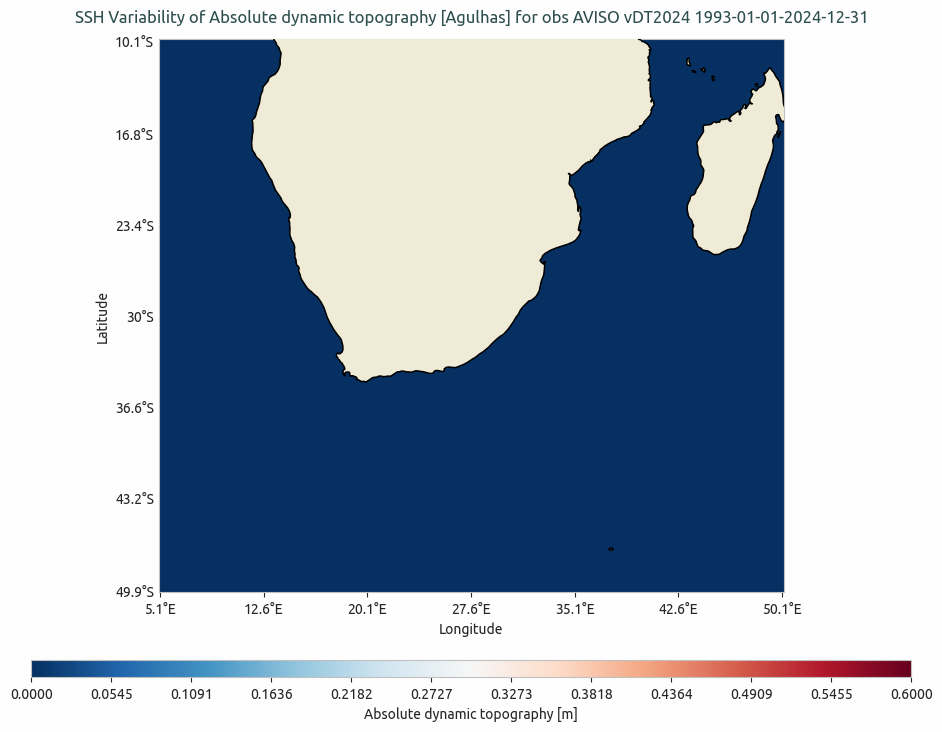

In [26]:
%%time
# Test 01 compare: Plot SSH difference from 2000-01-01 to 2002-12-31
# It is important to choose a correct 'tgt_grid_name' so that the data aligns with land mask
plot_dataset_ref = {"catalog": "obs", "model": "AVISO", "exp":"vDT2024", 'region': 'Agulhas', 'lon_limits': [5, 50], 'lat_limits': [-10, -50], 'proj': 'plate_carree', 'proj_params': {}, "tgt_grid_name":tgt_grid_name,}

plot_class.plot(dataset_std=diff, **plot_dataset_ref, startdate=_startdate, enddate=_enddate, vmin=0.0, vmax=0.6)

In [27]:
#############################
### Results differ when label NaN as ZEROS in the welforf variance function 
### the built-in function and Welford implementation give same result when not 
### skip NaNs

In [28]:
%%time
# STD from 1993-01-01 to 2024-12-31 
welford_stats = welford_statistics(data=_data, var=var, fillnan=False, statistics=statistics, state_save=False, outputdir=outputdir)
welford_std = np.sqrt(welford_stats["variance"])

CPU times: user 4min 19s, sys: 3min 29s, total: 7min 48s
Wall time: 7min 57s


In [29]:
%%time
# STD using xarray from 1993-01-01 to 2024-12-31  
std = _data.std(dim="time", skipna=False).compute()

CPU times: user 1min 43s, sys: 2min 19s, total: 4min 2s
Wall time: 4min 5s


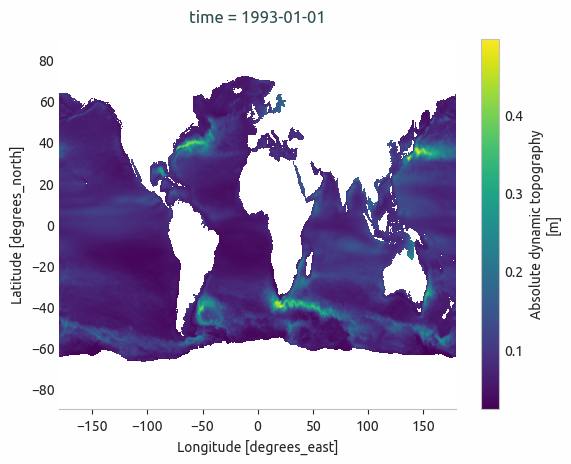

In [30]:
welford_std.plot()

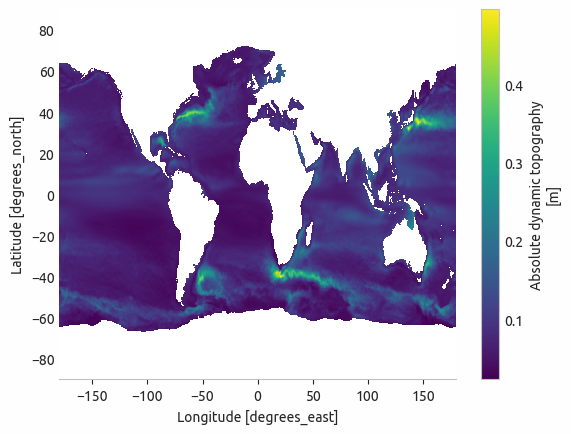

In [31]:
std.plot()

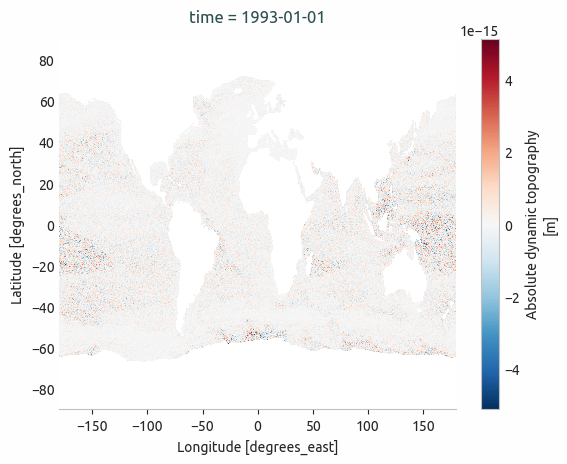

In [32]:
_diff = welford_std - std
_diff.plot()